# pMMR: Neighborhood analysis with just immune cells - normalizing by area and based on comparisons of interest

Manish wants to focus on just immune cells to see what going on with them. Here we will normalize the proportions based on the whole area of each ROI. 

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import time
import sys
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import seaborn as sns
import math
import os
import re

from scipy.spatial import cKDTree
from scipy.spatial import distance_matrix
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel

from itertools import combinations
import pandas as pd
import statsmodels.stats.multitest as smm

import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

The ROIs I am working with:

In [2]:
path = "/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/"

all_files = os.listdir(path)
pattern = re.compile(r'(.+)_sigma_binary_res')

# Extract matching sample names
sample_names = []
for file in all_files:
    match = pattern.match(file)
    if match:
        sample_names.append(match.group(1)) 

In [3]:
sample_names

['23257_A7_T3_tumor_bed',
 'BMS23-6679_C_tumor',
 'S23-38315_A3_tumor_inner',
 'BMS23-11362_C8_tumor_inner',
 'BMSS23-8749_28835_tumor',
 'S24-12214_C1_tumor',
 'BMS23-9784_A6_31737_tumor_bed',
 'S24-22889_A6_tumor_inner',
 'S23-47115_A6_tumor_bed',
 'S24-11672_G1_tumor',
 'S23-18584_A5_tumor_bed',
 'S24-35674_A9_tumor_inner',
 'S24-21915_A5_tumor_bed',
 'S23-21917_A6_tumor_bed',
 'BMS23-7393_C_tumor',
 'BMS24-11260_D_tumor',
 'BMS23-39313_C_tumor']

In [4]:
#create def to create a new table:
all_sample_merged_table= []
for sample_name in sample_names:
    annota_table = pd.read_table(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/cell_annotation.txt')
    raw_table = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/raw_metadata.csv')
    #print(annota_table['cell_id'].isin(raw_table['Object Id']).all())
    merged_table = pd.merge(
        raw_table,
        annota_table,
        left_on='Object Id',
        right_on='cell_id',
        how='inner'
    )
    merged_table['sample_region']=sample_name
    all_sample_merged_table.append(merged_table)

all_sample_merged_table = pd.concat(all_sample_merged_table, axis=0).reset_index(drop=True)

In [5]:
all_zscore_table= []
for sample_name in sample_names:
    norm_data = pd.read_csv(f'/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/{sample_name}_sigma_binary_res/z_score_normalization.csv')
    norm_data['sample_region']=sample_name
    all_zscore_table.append(norm_data)

all_zscore_table = pd.concat(all_zscore_table, axis=0).reset_index(drop=True)

In [6]:
all_sample_merged_table2 = all_sample_merged_table

In [7]:
all_sample_merged_table2.loc[all_sample_merged_table2['sample_region'] == 'BMS23-11362_C8_tumor_inner', 'sample_region'] = 'BMS23-11362_C8_tumor_bed'

In [8]:
normalized_df = all_sample_merged_table2.merge(all_zscore_table, on=['cell_id', 'sample_region'], how='left')


In [9]:
#rename cell types
probes_list =pd.read_csv("/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/probes_cell_type_table.csv",header=0)
normalized_df = pd.merge(normalized_df, probes_list, on="celll_type")


In [10]:
#normalized_df.columns

In [11]:
#select just the sample names, cell type of interest, X_mean and Y_mean and Cell Area
columns_to_Select = ['sample_region','new_cell_type_name','Cell Area (µm²)','xmean', 'ymean']
sub_df = normalized_df[columns_to_Select]

In [12]:
regions = ["tumor_inner", "tumor_bed", "tumor"]

# Create regex pattern
pattern = re.compile(rf"({'|'.join(regions)})$")

# Split into sample_id and region
data = []
for s in sub_df['sample_region']:
    match = pattern.search(s)
    if match:
        region = match.group(1)
        sample_id = s.replace("_" + region, "")
    else:
        region = "other"
        sample_id = s
    data.append((sample_id, region))

df = pd.DataFrame(data, columns=["Sample_name", "ROI"])

In [13]:
sub_df['Sample_name']=df['Sample_name'].values
sub_df['ROI']=df['ROI'].values

/tmp/ipykernel_42613/3721613111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['Sample_name']=df['Sample_name'].values
/tmp/ipykernel_42613/3721613111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df['ROI']=df['ROI'].values


In [14]:
samples_to_remove = ['BMS23-7393_C_tumor','BMS23-9784_A6_31737_tumor_bed','BMS23-11362_C8_tumor_bed']
sub_df = sub_df[~sub_df['sample_region'].isin(samples_to_remove)]


In [15]:
sample_map = pd.read_csv("/SSD/maa7095/spatial_techniques/manish_comet/sep_new_ROI/sample_conditions.csv")  
sample_map

,Sample_name,ROI,Condition,MSI,Internal
0,23257_A7_T3,tumor_bed,Responder,Stable,Resection
1,BMS23-11362_C8,tumor_bed,Responder,High,NaN
2,BMS23-39313_C,tumor,Responder,Stable,Baseline
3,BMS23-6679_C,tumor,Baseline,Stable,Baseline
4,BMS23-7393_C,tumor,Baseline,High,Baseline
5,BMS23-9784_A6_31737,tumor_bed,Responder,High,Resection
6,BMS24-11260_D,tumor,Baseline,Stable,Baseline
7,BMSS23-8749_28835,tumor,Non-responder,Stable,Resection
8,S23-18584_A5,tumor_bed,Responder,Stable,NaN
9,S23-21917_A6,tumor_bed,Responder,Stable,NaN


In [16]:
sub_df = pd.merge(
    sub_df, sample_map,
    left_on=["Sample_name", "ROI"],
    right_on=["Sample_name", "ROI"],
    how="inner"
)

In [17]:
sub_df['Sample_name'].unique()

array(['23257_A7_T3', 'BMS23-6679_C', 'S23-38315_A3', 'BMSS23-8749_28835',
       'S24-12214_C1', 'S24-22889_A6', 'S23-47115_A6', 'S24-11672_G1',
       'S23-18584_A5', 'S24-35674_A9', 'S24-21915_A5', 'S23-21917_A6',
       'BMS24-11260_D', 'BMS23-39313_C'], dtype=object)

In [18]:
#they have decided to combine cell types.
sub_df["combined_names"]=sub_df["new_cell_type_name"]
sub_df.loc[sub_df['new_cell_type_name'] == 'CD4', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4 (CD4_Tcell)', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD4_LAG3_Tcell', 'combined_names'] = 'CD4_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD8', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD8 (CD8_Tcell)', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD8_LAG3_Tcell', 'combined_names'] = 'CD8_T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4_CD8 (Tcell)', 'combined_names'] = 'T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'LAG3_Tcell', 'combined_names'] = 'T_cell'
sub_df.loc[sub_df['new_cell_type_name'] == 'FOXP3', 'combined_names'] = 'T_reg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_FOXP3 (T_regs)', 'combined_names'] = 'T_reg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD8_FOXP3 (CD8_Tregs)', 'combined_names'] = 'CD8_Treg'
sub_df.loc[sub_df['new_cell_type_name'] == 'CD3E_CD4_FOXP3 (CD4_Tregs)', 'combined_names'] = 'CD4_Treg'
sub_df.loc[sub_df['new_cell_type_name'] == 'Macrophages', 'combined_names'] = 'M1_Macrophages'
sub_df.loc[sub_df['new_cell_type_name'] == 'Th2_Macrophage', 'combined_names'] = 'M2_Macrophages'

In [19]:
celltype_colors = {
    "NK": "#1f77b4",
    "CD8_T_cell": "#2ca02c",
    "Endothelial": "#d62728",
    "Unknown": "#843c39",
    "B_cell": "#8c564b",
    "T_reg": "#e377c2",
    "Lymphatic_endothelium": "#7f7f7f",
    "Smooth_muscle": "#aec7e8",
    "CD8_Treg": "#ffbb78",
    "CD4_T_cell": "#98df8a",
    "M1_Macrophages": "#c5b0d5",
    "T_cell": "#c49c94",
    "Epithelial": "#f7b6d2",
    "CD4_Treg": "#393b79",
    "Stromal": "#637939",
    "M2_Macrophages": "#ff9896",
    "Plasma": "#9467bd"
}

Get the counts of all the differnet cell types and normalize them divind them by the whole area of the differnet ROIS.

In [20]:
counts_table = pd.crosstab(sub_df['sample_region'],sub_df['combined_names'])

In [21]:
area_sum = sub_df.groupby("sample_region")["Cell Area (µm²)"].sum()

In [22]:
normalized_area_table = counts_table.div(area_sum, axis=0)* 1000

In [23]:
unique_pairs = sub_df[['sample_region', 'Condition', "MSI", "Internal"]].drop_duplicates()
normalized_area_table_reset = normalized_area_table.reset_index()

merged_table = normalized_area_table_reset.merge(
    unique_pairs,
    on="sample_region",
    how="left"
)


In [24]:
#merged_table.columns

In [25]:
immune_cells = ['B_cell', 'CD4_T_cell', 'CD4_Treg','CD8_T_cell', 'CD8_Treg','Plasma',"T_reg", 'M1_Macrophages', 'M2_Macrophages', 
                'sample_region', 'Condition', 'MSI','Internal']
immune_normalized_area_table = merged_table[immune_cells]

# Proportion differences

## First comparison Responders vs Non-responders
Just internal tumor and no Peritumoral area

In [26]:
conditions_interest = ["Responder","Non-responder"]
ROI_interest = ["tumor_bed","tumor_inner"]

In [27]:
sub_interest1 = sub_df[sub_df['Condition'].isin(conditions_interest)]
sub_interest1 = sub_interest1[sub_interest1['ROI'].isin(ROI_interest)]
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]

In [28]:
interest_sample_sub = immune_normalized_area_table[immune_normalized_area_table['sample_region'] == "BMSS23-8749_28835_tumor"]
subset_table = pd.concat([subset_table, interest_sample_sub], axis=0)
table_to_prov1 = subset_table.set_index(["Condition", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["Condition", "sample_region"])
table_to_prov1.drop(['MSI','Internal'], axis=1, inplace=True)

In [29]:
#table_to_prov1.index.get_level_values("sample_region")


In [30]:
def t_test_plot_test(prop_table, columns_interest, sample_order=None, t_test_type=ttest_ind):
    dataframe_interest = prop_table.copy()
    dataframe_interest.index.names = [columns_interest, 'sample_region']

    # ✅ Enforce custom condition order if provided
    if sample_order is not None:
        dataframe_interest = dataframe_interest.reorder_levels([columns_interest, 'sample_region'])
        dataframe_interest = (
            dataframe_interest
            .loc[dataframe_interest.index.get_level_values(columns_interest)
                 .isin(sample_order)]
            .sort_index(level='sample_region')
        )
        # Make the first index level categorical to control order
        cond_order = pd.Categorical(
            dataframe_interest.index.get_level_values(columns_interest),
            categories=sample_order,
            ordered=True
        )
        dataframe_interest = dataframe_interest.iloc[np.argsort(cond_order)]

    colors = [celltype_colors.get(ct, "#808080") for ct in dataframe_interest.columns]

    ax = dataframe_interest.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)

    # Add separator lines between conditions
    conditions = dataframe_interest.index.get_level_values(0)
    for i in range(1, len(conditions)):
        if conditions[i] != conditions[i - 1]:
            ax.axhline(i - 0.5, color="black", linewidth=1)

    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(False)

    plt.title('Density of Cell Types per Sample')
    plt.xlabel('Cell type density')
    plt.ylabel('Sample (grouped by Condition)')
    plt.tight_layout()
    plt.show()

    dataframe_interest[columns_interest] = dataframe_interest.index.get_level_values(columns_interest)
    results = []

    conditions = dataframe_interest[columns_interest].unique()

    for cell_type in dataframe_interest.columns:
        if cell_type != columns_interest:
            for cond1, cond2 in combinations(conditions, 2):
                group1 = dataframe_interest.loc[dataframe_interest[columns_interest] == cond1, cell_type]
                group2 = dataframe_interest.loc[dataframe_interest[columns_interest] == cond2, cell_type]

                mean1 = group1.mean()
                mean2 = group2.mean()

                if t_test_type == ttest_rel:
                    t_stat, p_val = t_test_type(group1, group2)
                else:
                    t_stat, p_val = t_test_type(group1, group2, equal_var=False)

                #t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
                direction = f"up_in_{cond1}" if mean1 > mean2 else f"up_in_{cond2}"

                results.append({
                    "cell_type": cell_type,
                    "comparison": f"{cond1}_vs_{cond2}",
                    f"{cond1}_mean": mean1,
                    f"{cond2}_mean": mean2,
                    "t_stat": t_stat,
                    "p_val": p_val,
                    "direction": direction
                })

    results_df = pd.DataFrame(results)
    results_df["p_adj"] = smm.multipletests(results_df["p_val"], method="fdr_bh")[1]

    return ax, results_df


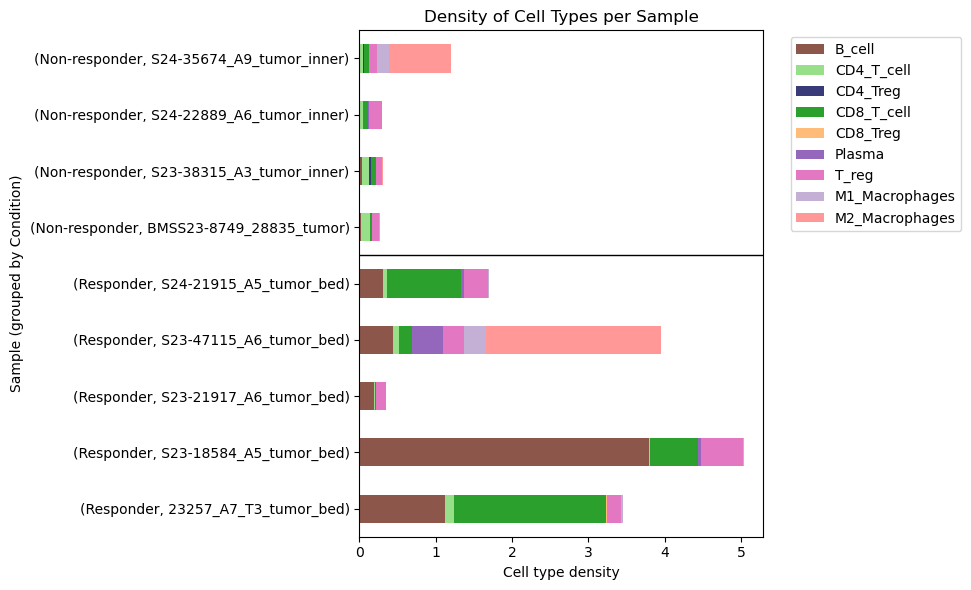

In [31]:
ax, results_df = t_test_plot_test(table_to_prov1, "Condition",  sample_order=["Responder", "Non-responder"])

In [32]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Responder_mean,Non-responder_mean,t_stat,p_val,direction,p_adj


### All the p values for ecah comparison

In [33]:
results_df

,cell_type,comparison,Responder_mean,Non-responder_mean,t_stat,p_val,direction,p_adj
0,B_cell,Responder_vs_Non-responder,1.169990,0.018102,1.707214,0.162961,up_in_Responder,0.366663
1,CD4_T_cell,Responder_vs_Non-responder,0.054905,0.069821,-0.531426,0.611670,up_in_Non-responder,0.710973
2,CD4_Treg,Responder_vs_Non-responder,0.000443,0.012652,-2.435956,0.092379,up_in_Non-responder,0.353159
3,CD8_T_cell,Responder_vs_Non-responder,0.756260,0.054653,1.986917,0.117720,up_in_Responder,0.353159
4,CD8_Treg,Responder_vs_Non-responder,0.003057,0.000471,0.866123,0.434577,up_in_Responder,0.651865
5,Plasma,Responder_vs_Non-responder,0.097525,0.001000,1.242825,0.281802,up_in_Responder,0.507244
6,T_reg,Responder_vs_Non-responder,0.286806,0.110635,2.321355,0.072043,up_in_Responder,0.353159
7,M1_Macrophages,Responder_vs_Non-responder,0.069950,0.044417,0.387151,0.710973,up_in_Responder,0.710973
8,M2_Macrophages,Responder_vs_Non-responder,0.460233,0.205736,0.506105,0.632558,up_in_Responder,0.710973


### t-test between the whole immune environment

In [34]:
table_to_prov1['immune_prop']=table_to_prov1.iloc[:, 0:].sum(axis=1)

In [35]:
df_reset = table_to_prov1.reset_index()

In [36]:
from scipy import stats

conditions = df_reset['Condition'].unique()

# Step 4: pairwise t-tests
for g1, g2 in combinations(conditions, 2):
    a = df_reset.loc[df_reset['Condition'] == g1, 'immune_prop']
    b = df_reset.loc[df_reset['Condition'] == g2, 'immune_prop']
    if len(a) > 1 and len(b) > 1:
        mean1 = a.mean()
        mean2 = b.mean()
        direction = f"up_in_{g1}" if mean1 > mean2 else f"up_in_{g2}"
        
        t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
        print(f"{g1} vs {g2} | mean1={mean1:.3f}, mean2={mean2:.3f} | "
              f"t={t_stat:.3f} | p={p_val:.4g} | {direction}")


Non-responder vs Responder | mean1=0.517, mean2=2.899 | t=-2.753 | p=0.04408 | up_in_Responder


## Third comparison: Baseline vs Resections: paired-test

In [37]:
sub_interest1 = sub_df[sub_df['Internal'].notna()]
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]
subset_table = subset_table[subset_table['sample_region']!="S24-12214_C1_tumor"]
table_to_prov1 = subset_table.set_index(["Internal", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["Internal", "sample_region"])
table_to_prov1.drop(['Condition','MSI'], axis=1, inplace=True)

In [38]:
table_to_prov1.index.get_level_values("sample_region") 

Index(['BMS23-39313_C_tumor', 'BMS23-6679_C_tumor', 'BMS24-11260_D_tumor',
       'S24-11672_G1_tumor', '23257_A7_T3_tumor_bed',
       'BMSS23-8749_28835_tumor', 'S23-47115_A6_tumor_bed',
       'S24-22889_A6_tumor_inner'],
      dtype='object', name='sample_region')

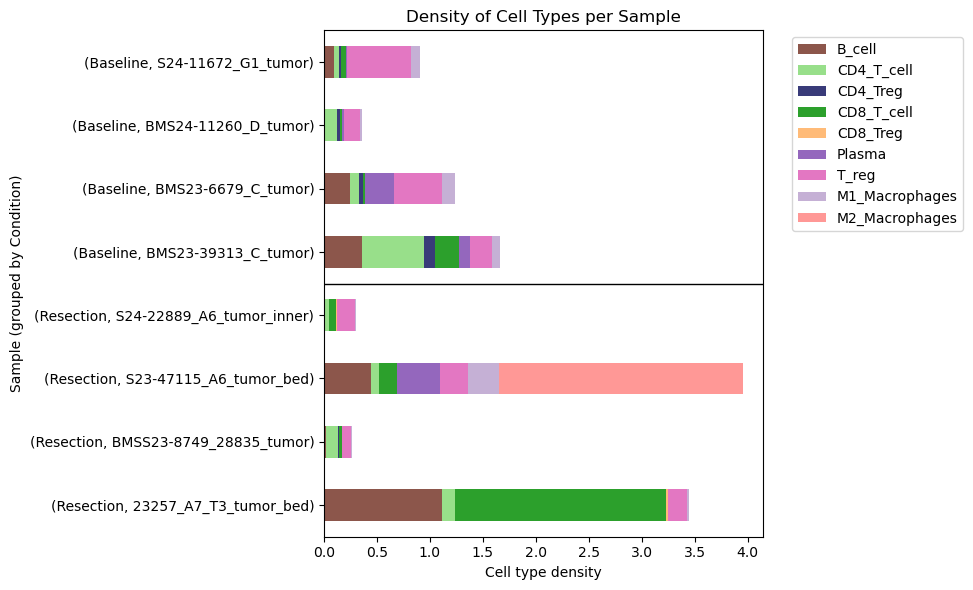

In [39]:
ax, results_df = t_test_plot_test(table_to_prov1, "Internal", sample_order=["Resection", "Baseline"], t_test_type= ttest_rel)

In [40]:
results_df[results_df['p_val']<0.05]


,cell_type,comparison,Resection_mean,Baseline_mean,t_stat,p_val,direction,p_adj


In [41]:
results_df

,cell_type,comparison,Resection_mean,Baseline_mean,t_stat,p_val,direction,p_adj
0,B_cell,Resection_vs_Baseline,0.398299,0.176344,0.976964,0.400638,up_in_Resection,0.600956
1,CD4_T_cell,Resection_vs_Baseline,0.085367,0.207252,-1.071063,0.362649,up_in_Baseline,0.600956
2,CD4_Treg,Resection_vs_Baseline,0.003088,0.048796,-2.298814,0.105103,up_in_Baseline,0.600956
3,CD8_T_cell,Resection_vs_Baseline,0.565891,0.075839,1.147184,0.334500,up_in_Resection,0.600956
4,CD8_Treg,Resection_vs_Baseline,0.003772,0.002424,0.406122,0.711885,up_in_Resection,0.915281
5,Plasma,Resection_vs_Baseline,0.102333,0.100272,0.014618,0.989255,up_in_Resection,0.989255
6,T_reg,Resection_vs_Baseline,0.176605,0.352810,-1.360900,0.266757,up_in_Baseline,0.600956
7,M1_Macrophages,Resection_vs_Baseline,0.081821,0.077687,0.045028,0.966914,up_in_Resection,0.989255
8,M2_Macrophages,Resection_vs_Baseline,0.574642,0.000348,1.000042,0.390985,up_in_Resection,0.600956


## 4 comparison: Baseline vs Resections for Responder: paired-test

In [42]:
sub_interest1 = sub_df[sub_df['Internal'].notna()]
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]

In [43]:
test_to_subset = ['Responder','Baseline']
subset_table = subset_table[subset_table['Condition'].isin(test_to_subset)]
non_Responder = ['BMS23-6679_C_tumor','BMS24-11260_D_tumor']
subset_table = subset_table[~subset_table['sample_region'].isin(non_Responder)]
subset_table = subset_table[subset_table['sample_region']!="S24-12214_C1_tumor"]
table_to_prov1 = subset_table.set_index(["Internal", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["Internal", "sample_region"])
table_to_prov1.drop(['Condition','MSI'], axis=1, inplace=True)

In [44]:
table_to_prov1.index.get_level_values("sample_region")


Index(['BMS23-39313_C_tumor', 'S24-11672_G1_tumor', '23257_A7_T3_tumor_bed',
       'S23-47115_A6_tumor_bed'],
      dtype='object', name='sample_region')

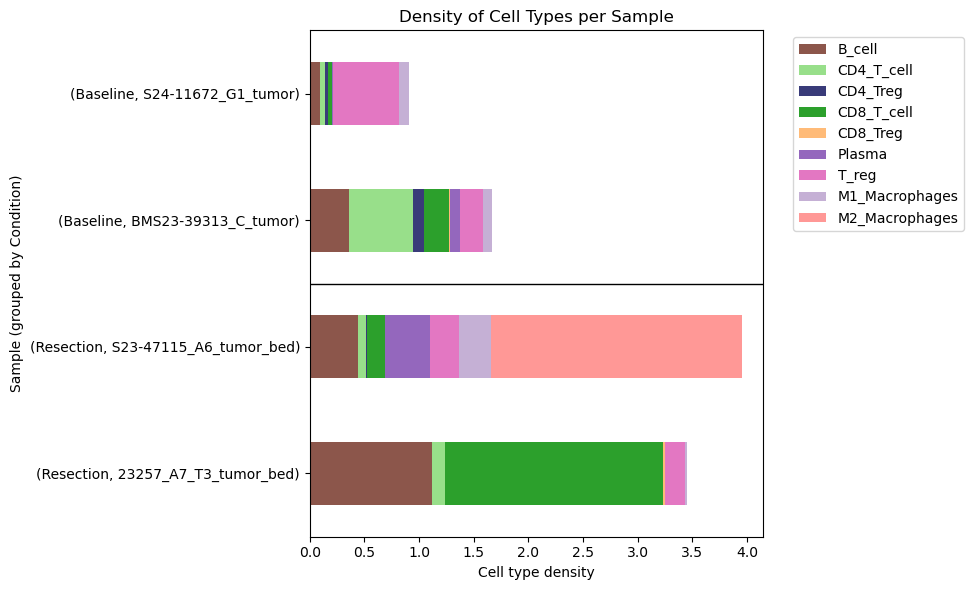

In [45]:
ax, results_df = t_test_plot_test(table_to_prov1, "Internal", sample_order=["Resection", "Baseline"],t_test_type= ttest_rel)

In [46]:
results_df[results_df['p_val']<0.05]


,cell_type,comparison,Resection_mean,Baseline_mean,t_stat,p_val,direction,p_adj


## 5 comparison: Baseline vs Resections for Non-Responder: paired-test

In [47]:
sub_interest1 = sub_df[sub_df['Internal'].notna()]
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]

In [48]:
test_to_subset = ['Non-responder','Baseline']
subset_table = subset_table[subset_table['Condition'].isin(test_to_subset)]

In [49]:

Responder = ['BMS23-7393_C_tumor']
subset_table = subset_table[~subset_table['sample_region'].isin(Responder)]
table_to_prov1 = subset_table.set_index(["Internal", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["Internal", "sample_region"])
table_to_prov1.drop(['Condition','MSI'], axis=1, inplace=True)

In [50]:
table_to_prov1.index.get_level_values("sample_region")


Index(['BMS23-6679_C_tumor', 'BMS24-11260_D_tumor', 'BMSS23-8749_28835_tumor',
       'S24-22889_A6_tumor_inner'],
      dtype='object', name='sample_region')

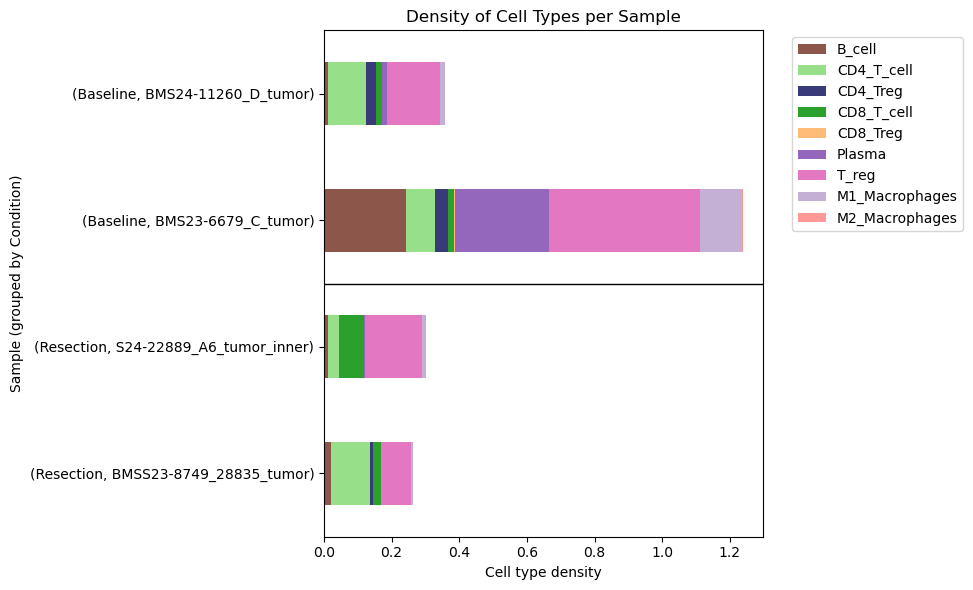

In [51]:
ax, results_df = t_test_plot_test(table_to_prov1, "Internal", sample_order=["Resection", "Baseline"] ,t_test_type= ttest_rel)

In [52]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Resection_mean,Baseline_mean,t_stat,p_val,direction,p_adj
2,CD4_Treg,Resection_vs_Baseline,0.005207,0.033723,-21.298595,0.029868,up_in_Baseline,0.268815


## 6 comparison: within Baseline: Responders vs Non-responders

In [53]:
sub_interest1 = sub_df[sub_df['Internal']=="Baseline"]
sub_interest1['Baseline_comp']='Responder'
sub_interest1.loc[sub_interest1['sample_region'] == 'BMS24-11260_D_tumor', 'Baseline_comp'] = 'Non-responder'
sub_interest1.loc[sub_interest1['sample_region'] == 'BMS23-6679_C_tumor', 'Baseline_comp'] = 'Non-responder'

/tmp/ipykernel_42613/709589333.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_interest1['Baseline_comp']='Responder'


In [54]:
to_merge = sub_interest1[['sample_region','Baseline_comp']].drop_duplicates()

In [55]:
subset_table = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sub_interest1['sample_region'].unique())]
subset_table = pd.merge(
    subset_table, to_merge,
    left_on=['sample_region'],
    right_on=['sample_region'],
    how="inner"
)

In [56]:
table_to_prov1 = subset_table.set_index(["Baseline_comp", "sample_region"])
table_to_prov1 = table_to_prov1.sort_index(level=["Baseline_comp", "sample_region"])
table_to_prov1.drop(['Condition','MSI','Internal'], axis=1, inplace=True)

In [57]:
table_to_prov1.index.get_level_values("sample_region")


Index(['BMS23-6679_C_tumor', 'BMS24-11260_D_tumor', 'BMS23-39313_C_tumor',
       'S24-11672_G1_tumor', 'S24-12214_C1_tumor'],
      dtype='object', name='sample_region')

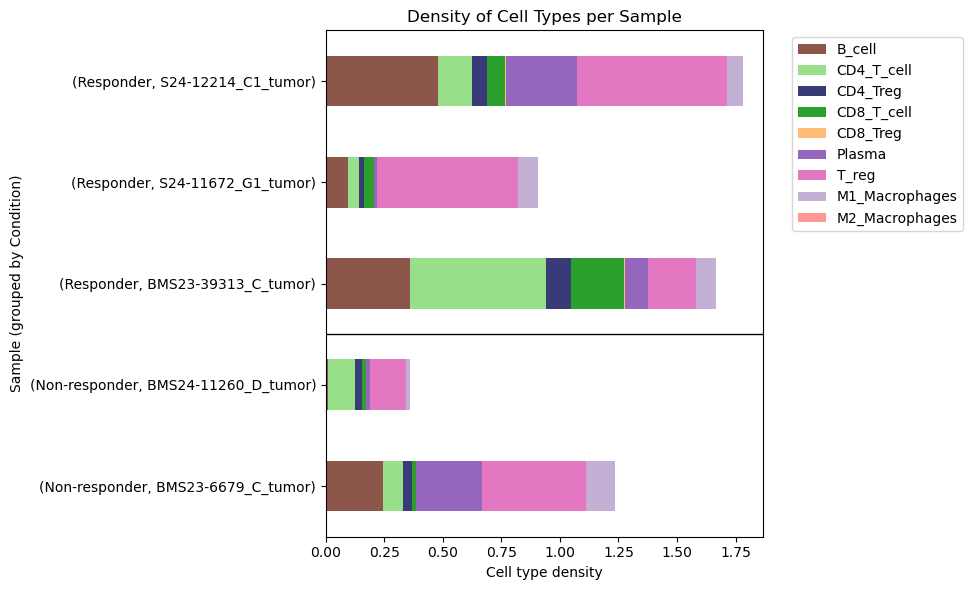

In [58]:
ax, results_df = t_test_plot_test(table_to_prov1, "Baseline_comp")

In [59]:
results_df[results_df['p_val']<0.05]


,cell_type,comparison,Non-responder_mean,Responder_mean,t_stat,p_val,direction,p_adj


## 7: comparison based on Non-reponders with WT and mutations of interest

In [60]:
sample_to_subset = ['S24-35674_A9_tumor_inner','S24-22889_A6_tumor_inner','S23-38315_A3_tumor_inner','BMSS23-8749_28835_tumor']
mutation_df = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sample_to_subset)]

In [61]:
#add mutation information to the samples
mutation_df['mutation_state']='WT'

/tmp/ipykernel_42613/2604617412.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutation_df['mutation_state']='WT'


In [62]:
mutation_df.loc[mutation_df['sample_region'] == 'S24-22889_A6_tumor_inner', 'mutation_state'] = 'BRAF_V600R'
mutation_df.loc[mutation_df['sample_region'] == 'S24-35674_A9_tumor_inner', 'mutation_state'] = 'KRAS_G12D'


In [63]:
mutation_df = mutation_df.drop(columns=["Condition", "MSI", "Internal"])
mutation_df = mutation_df.set_index(["mutation_state", "sample_region"])


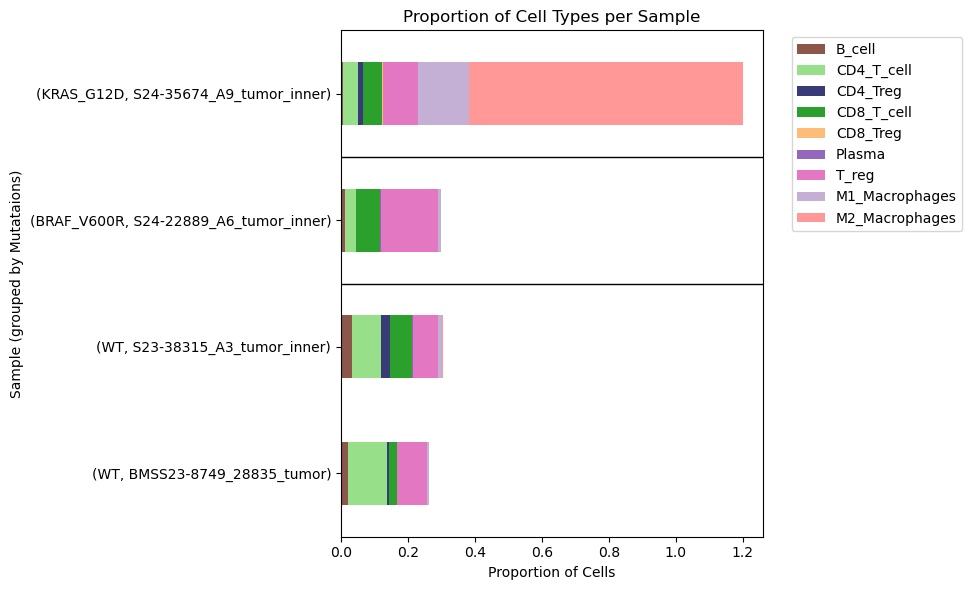

In [64]:
colors = [celltype_colors.get(ct, "#808080")  # fallback = grey if not in dict
              for ct in mutation_df.columns]

ax = mutation_df.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)

# add separator lines between conditions
# get index levels
conditions = mutation_df.index.get_level_values(0)
for i in range(1, len(conditions)):
    if conditions[i] != conditions[i-1]:
        ax.axhline(i-0.5, color="black", linewidth=1)  # separator

# legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(False)

plt.title('Proportion of Cell Types per Sample')
plt.xlabel('Proportion of Cells')
plt.ylabel('Sample (grouped by Mutataions)')
plt.tight_layout()
plt.show()


## 8 comparison: baseline vs resection change in NEST2-04 (BRAF V600R) vs Nest1-04 (WT)

In [65]:
immune_normalized_area_table['sample_region'].unique()

array(['23257_A7_T3_tumor_bed', 'BMS23-39313_C_tumor',
       'BMS23-6679_C_tumor', 'BMS24-11260_D_tumor',
       'BMSS23-8749_28835_tumor', 'S23-18584_A5_tumor_bed',
       'S23-21917_A6_tumor_bed', 'S23-38315_A3_tumor_inner',
       'S23-47115_A6_tumor_bed', 'S24-11672_G1_tumor',
       'S24-12214_C1_tumor', 'S24-21915_A5_tumor_bed',
       'S24-22889_A6_tumor_inner', 'S24-35674_A9_tumor_inner'],
      dtype=object)

In [66]:
sample_to_subset = ['S24-22889_A6_tumor_inner','BMS24-11260_D_tumor','BMSS23-8749_28835_tumor', 'BMS23-6679_C_tumor']
mutation_df = immune_normalized_area_table[immune_normalized_area_table['sample_region'].isin(sample_to_subset)]

In [67]:
#add mutation information to the samples
mutation_df['mutation_state']='Baseline'

/tmp/ipykernel_42613/54563156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutation_df['mutation_state']='Baseline'


In [68]:
mutation_df.loc[mutation_df['sample_region'] == 'S24-22889_A6_tumor_inner', 'mutation_state'] = 'Resection'
mutation_df.loc[mutation_df['sample_region'] == 'BMSS23-8749_28835_tumor', 'mutation_state'] = 'Resection'
mutation_df = mutation_df.drop(columns=["Condition", "MSI", "Internal"])
mutation_df = mutation_df.set_index(["mutation_state", "sample_region"])


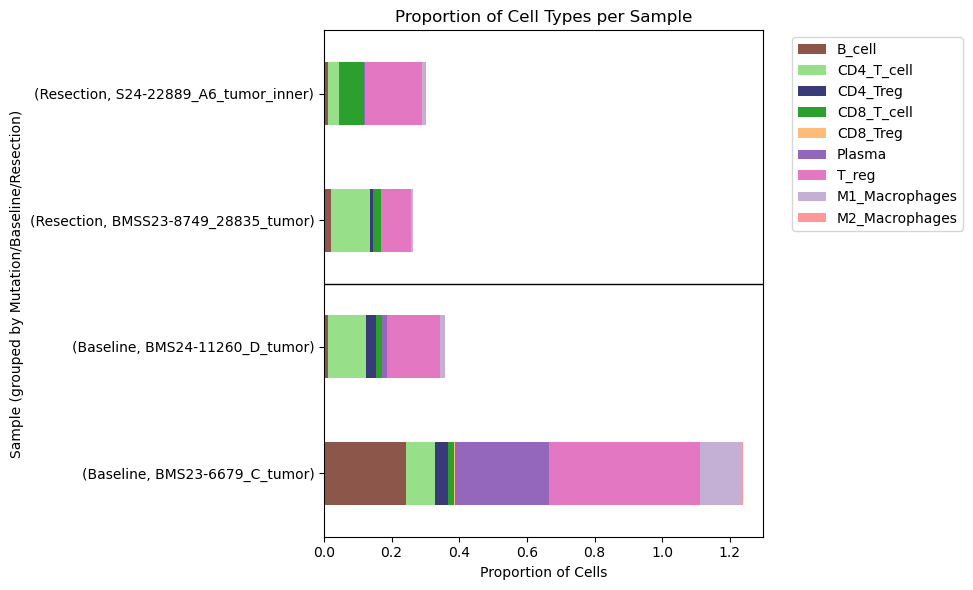

In [69]:
colors = [celltype_colors.get(ct, "#808080")  # fallback = grey if not in dict
              for ct in mutation_df.columns]
ax = mutation_df.plot(kind='barh', stacked=True, figsize=(10, 6), color=colors)

# add separator lines between conditions
# get index levels
conditions = mutation_df.index.get_level_values(0)
for i in range(1, len(conditions)):
    if conditions[i] != conditions[i-1]:
        ax.axhline(i-0.5, color="black", linewidth=1)  # separator

# legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(False)

plt.title('Proportion of Cell Types per Sample')
plt.xlabel('Proportion of Cells')
plt.ylabel('Sample (grouped by Mutation/Baseline/Resection)')
plt.tight_layout()
plt.show()

## 8: All samples


In [70]:
sub_df_all = immune_normalized_area_table.copy()
sub_df_all['All'] = sub_df_all['Internal'].values

In [71]:

sub_df_all.loc[sub_df_all['sample_region'] == '23257_A7_T3_tumor_bed', 'All'] = 'Responder'
#sub_df_all.loc[sub_df_all['sample_region'] == 'BMS23-11362_C8_tumor_bed', 'All'] = 'Responder'
#sub_df_all.loc[sub_df_all['sample_region'] == 'BMS23-9784_A6_31737_tumor_bed', 'All'] = 'Responder'
sub_df_all.loc[sub_df_all['sample_region'] == 'S23-18584_A5_tumor_bed', 'All'] = 'Responder'
sub_df_all.loc[sub_df_all['sample_region'] == 'S23-21917_A6_tumor_bed', 'All'] = 'Responder'
sub_df_all.loc[sub_df_all['sample_region'] == 'S23-47115_A6_tumor_bed', 'All'] = 'Responder'
sub_df_all.loc[sub_df_all['sample_region'] == 'S24-21915_A5_tumor_bed', 'All'] = 'Responder'


sub_df_all.loc[sub_df_all['sample_region'] == 'BMSS23-8749_28835_tumor', 'All'] = 'Non-Responder'
sub_df_all.loc[sub_df_all['sample_region'] == 'S23-38315_A3_tumor_inner', 'All'] = 'Non-Responder'
sub_df_all.loc[sub_df_all['sample_region'] == 'S24-22889_A6_tumor_inner', 'All'] = 'Non-Responder'
sub_df_all.loc[sub_df_all['sample_region'] == 'S24-35674_A9_tumor_inner', 'All'] = 'Non-Responder'


In [72]:
sub_df_all.drop(['Condition','MSI','Internal'], axis=1, inplace=True)

In [73]:
sub_df_all = sub_df_all.set_index(["All", "sample_region"])
sub_df_all = sub_df_all.sort_index(level=["All", "sample_region"])

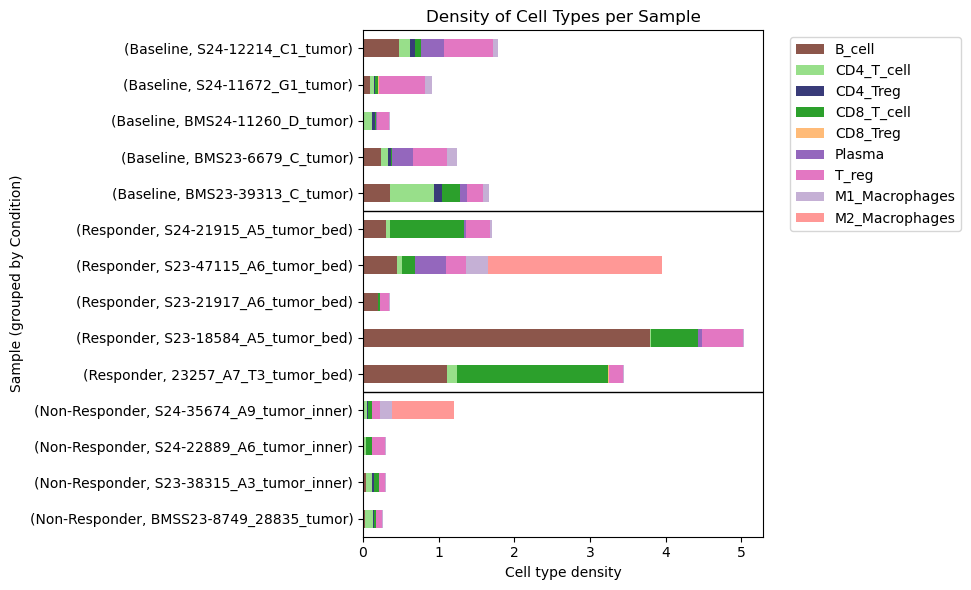

In [74]:
ax, results_df = t_test_plot_test(sub_df_all, "All", sample_order=["Non-Responder", "Responder","Baseline"])

In [75]:
results_df[results_df['p_val']<0.05]

,cell_type,comparison,Non-Responder_mean,Responder_mean,t_stat,p_val,direction,Baseline_mean,p_adj
8,CD4_Treg,Responder_vs_Baseline,NaN,0.000443,-3.389834,0.027510,up_in_Baseline,0.052388,0.311779
13,CD8_Treg,Non-Responder_vs_Baseline,0.000471,NaN,-2.937944,0.031184,up_in_Baseline,0.002602,0.311779
19,T_reg,Non-Responder_vs_Baseline,0.110635,NaN,-2.957168,0.037566,up_in_Baseline,0.410399,0.311779
